# COGS 108 - Data Checkpoint

## Authors

- Mia Mayer: Conceptualization, Project administration, Writing – review & editing
- Julia Visaya: Background research, Data curation (initial dataset exploration), Writing – original draft
- Hemi Kim: Data curation, Software, Methodology, Analysis, Visualization, Writing – review & editing
- Katelyn Ma: Data curation (Scorecard dataset), Software, Writing – original draft
- Catherine Do: Background research, Ethics writing, Writing – review & editing

## Research Question

Is there a statistically significant association between public college institutional funding levels and the median annual earnings of graduates ten years post-graduation in the United States? Funding will be measured using institution-level financial variables such as total revenue, instructional expenditures, and state and federal appropriations obtained from IPEDS/NCES. Graduate outcomes will be measured using the College Scorecard median earnings metric at approximately ten years after completion. To account for geographic and institutional differences, we will include controls for state/region, cost-of-living proxies (such as ACS median household income), and institutional scale (enrollment and degree completions). This is a statistical inference project, and we will use correlation and regression analyses to determine whether funding levels significantly predict long-term graduate earnings while controlling for these factors.


## Background and Prior Work

The funding of public higher education remains a central topic in debates regarding economic advancement, workforce outcomes, and the promotion of financial mobility in the United States. Public colleges and universities educate a significant proportion of the nation’s working population, as they receive financial backing from an integration of state support, tuition revenue, and federal funding.<a id="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) However, this degree of funding varies across public college and university districts as a result of differences in state budgets, enrollment rates, and regional economic priorities.<a id="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) These variations motivate our question of whether greater financial investment in higher education systems is associated with stronger long-term economic outcomes for graduates.

To study this relationship, we plan to use publicly available administrative datasets from the National Center for Education Statistics (NCES) and related federal education data systems. From NCES, we extracted or identified datasets that capture: (1) median earnings of graduates<a id="cite_ref-6"></a>[<sup>6</sup>](#cite_note-6), (2) institutional funding and revenue, (3) tuition and cost of attendance, (4) enrollment and completions, and (5) institutional characteristics such as location and size.<a id="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) Together, these datasets allow us to examine how funding levels relate to graduate earnings while accounting for institutional scale and geographic differences.

A key concern in comparing earnings across institutions is that similar salaries can imply different standards of living depending on local costs and regional economic conditions. To further contextualize earnings outcomes, we incorporate cost-of-living information using socioeconomic data from the U.S. Census Bureau (American Community Survey), enabling a more accurate comparison of earnings across regions by using a regional proxy such as median household income.<a id="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4)

This project also connects to prior work that evaluates the economic value of higher education, including student earnings outcomes and the opportunity costs of attending college. A previous COGS 108 project (“Are Universities Worth the Opportunity Cost?”) provides a relevant methodological reference for analyzing education-related economic outcomes using institutional-level data, and it motivates our emphasis on measurable labor market outcomes in a rigorous, data-driven framework.<a id="cite_ref-5"></a>[<sup>5</sup>](#cite_note-5)

---

1. <a id="cite_note-1"></a> [^](#cite_ref-1) National Center for Education Statistics (NCES). *Digest of Education Statistics*. https://nces.ed.gov/programs/digest/
2. <a id="cite_note-2"></a> [^](#cite_ref-2) NCES Condition of Education — Postsecondary Institution Revenue. https://nces.ed.gov/programs/coe/indicator/cud/postsecondary-institution-revenue
3. <a id="cite_note-3"></a> [^](#cite_ref-3) Integrated Postsecondary Education Data System (IPEDS) — Survey Components and Data Center. https://nces.ed.gov/ipeds/
4. <a id="cite_note-4"></a> [^](#cite_ref-4) U.S. Census Bureau — American Community Survey (ACS) Data Tables (including B19013). https://data.census.gov/ ; https://data.census.gov/table/ACSDT5Y2022.B19013
5. <a id="cite_note-5"></a> [^](#cite_ref-5) Previous COGS 108 Project (Sp17): *Are Universities Worth the Opportunity Cost?* https://github.com/COGS108/FinalProjects-Sp17/blob/master/081-FinalProject.ipynb
6. <a id="cite_note-6"></a> [^](#cite_ref-6) College Scorecard — Data Documentation and Bulk Downloads (median earnings). https://collegescorecard.ed.gov/data/


## Hypothesis


We predict a positive association between institutional funding per student and median earnings ten years after entry. Higher funding may allow institutions to provide better academic and career resources that improve students’ long-term earning potential. Because earnings vary substantially by major, we will control for the types of degrees offered at each institution. Specifically, we will include measures of degree composition (e.g., the proportion of graduates in higher-paying fields such as engineering, computer science, health, or business) using data from the College Scorecard. This helps ensure that any observed relationship between funding and earnings is not simply due to certain schools offering more high-paying majors. We expect funding to remain positively associated with earnings even after accounting for institutional size, geography, and degree mix.


## Data

### Data Overview

### Dataset #1: IPEDS Finance + Enrollment (2012)

- **Dataset Name:** IPEDS Compare Institutions extract (public 4-year institutions), Finance + Fall Enrollment
- **Link:** https://nces.ed.gov/ipeds/use-the-data (Compare Institutions tool)
- **Number of observations:** 711 institutions (public institutions selected in IPEDS tool)
- **Number of variables used:** 3 primary variables (plus institution name columns)
- **Key variables:**
  - `UnitID` (institution identifier used for merging)
  - `Instruction - Current year total (FY 2012)` (instructional expenditures, USD)
  - `Grand total (Fall 2012, all students total)` (fall enrollment count)
- **Shortcomings:**
  - Finance totals scale with institution size; we address this by computing instructional spending per student.
  - Missing values exist for some institutions (finance or enrollment not reported).

### Dataset #2: College Scorecard (Cohort 2012–13)

- **Dataset Name:** College Scorecard cohort file `MERGED2012_13_PP.csv`
- **Link:** https://collegescorecard.ed.gov/data/ (bulk download archive)
- **Number of observations:** 7,862 institutions (all sectors; we will later restrict to match IPEDS public institutions)
- **Number of variables:** 3,306 columns in the file; we use a small subset
- **Key variables:**
  - `UNITID` (institution identifier)
  - `MD_EARN_WNE_P10` (median earnings 10 years after entry, USD)
  - (additional institutional characteristics available for future controls)
- **Shortcomings:**
  - Earnings outcomes reflect both institution effects and student selection (non-causal).
  - Some institutions have missing earnings values due to small cohorts or reporting constraints.

### Combining datasets
We merge datasets using `UNITID`. We create an institutional funding measure comparable across schools by computing:
`funding_per_student_2012 = instructional_expenditures_2012 / enrollment_2012`.
We then regress `MD_EARN_WNE_P10` on `funding_per_student_2012` as a baseline model.


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
import os
import zipfile
import pandas as pd
import numpy as np

RAW_DIR = "data/00-raw"

# Make sure folder exists
os.makedirs(RAW_DIR, exist_ok=True)

# Files you already have (no auto-download)
ZIP_PATH = os.path.join(RAW_DIR, "College_Scorecard_Raw_Data_10032025.zip")
IPEDS_PATH = os.path.join(RAW_DIR, "ipeds_finance_enrollment_2012.csv")

# Extract scorecard zip if needed
if os.path.exists(ZIP_PATH):
    # Only extract if the cohort file is not already present
    cohort_path = os.path.join(RAW_DIR, "MERGED2012_13_PP.csv")
    if not os.path.exists(cohort_path):
        with zipfile.ZipFile(ZIP_PATH, "r") as z:
            z.extractall(RAW_DIR)
        print("Extracted Scorecard zip into:", RAW_DIR)
    else:
        print("Scorecard cohort file already extracted.")
else:
    print("Missing Scorecard zip at:", ZIP_PATH)

# Quick check
print("Raw dir files (sample):", sorted(os.listdir(RAW_DIR))[:20])
print("IPEDS exists?", os.path.exists(IPEDS_PATH))
print("Scorecard cohort exists?", os.path.exists(os.path.join(RAW_DIR, "MERGED2012_13_PP.csv")))


Scorecard cohort file already extracted.
Raw dir files (sample): ['.gitkeep', '.ipynb_checkpoints', 'College_Scorecard_Raw_Data_10032025.zip', 'Crosswalks', 'EF2022A.zip', 'F2223_F1A.zip', 'FieldOfStudyData1415_1516_PP.csv', 'FieldOfStudyData1516_1617_PP.csv', 'FieldOfStudyData1617_1718_PP.csv', 'FieldOfStudyData1718_1819_PP.csv', 'FieldOfStudyData1819_1920_PP.csv', 'FieldOfStudyData1920_2021_PP.csv', 'HD2022.zip', 'MERGED1996_97_PP.csv', 'MERGED1997_98_PP.csv', 'MERGED1998_99_PP.csv', 'MERGED1999_00_PP.csv', 'MERGED2000_01_PP.csv', 'MERGED2001_02_PP.csv', 'MERGED2002_03_PP.csv']
IPEDS exists? True
Scorecard cohort exists? True


### Dataset #1: IPEDS 2012 Instructional Spending + Enrollment

IPEDS provides standardized institution-level finance and enrollment data for U.S. colleges and universities. For this project, we use instructional expenditures for fiscal year 2012 (reported in current dollars) and total fall enrollment for Fall 2012 for public institutions.

Because total spending scales with institution size, we compute instructional spending per student by dividing instructional expenditures by total enrollment. This produces a funding intensity measure (dollars per enrolled student), which allows more meaningful comparisons across institutions of different sizes.

Potential concerns include missingness (some institutions may not report or may have suppressed values) and the fact that spending totals alone do not capture instructional quality or how effectively funds are allocated. We convert relevant columns to numeric format and drop rows with missing funding or enrollment values for the baseline analysis, while documenting how many rows are removed.

In [3]:
# Load IPEDS
ipeds = pd.read_csv(IPEDS_PATH)

# Keep and rename relevant columns
ipeds_clean = ipeds.rename(columns={
    "UnitID": "UNITID",
    "Instruction - Current year total (F1112_F1A_RV)": "instruction_exp_2012",
    "Grand total (EF2012_RV  All students total)": "enrollment_2012"
}).copy()

ipeds_clean = ipeds_clean[["UNITID", "instruction_exp_2012", "enrollment_2012"]]

# Convert types
ipeds_clean["UNITID"] = pd.to_numeric(ipeds_clean["UNITID"], errors="coerce")
ipeds_clean["instruction_exp_2012"] = pd.to_numeric(ipeds_clean["instruction_exp_2012"], errors="coerce")
ipeds_clean["enrollment_2012"] = pd.to_numeric(ipeds_clean["enrollment_2012"], errors="coerce")

# Missingness report
print("IPEDS missingness:\n", ipeds_clean.isna().mean().sort_values(ascending=False))

# Compute per-student funding (avoid divide-by-zero)
ipeds_clean = ipeds_clean[ipeds_clean["enrollment_2012"] > 0].copy()
ipeds_clean["funding_per_student_2012"] = ipeds_clean["instruction_exp_2012"] / ipeds_clean["enrollment_2012"]

print("IPEDS cleaned shape:", ipeds_clean.shape)
ipeds_clean.describe()

IPEDS missingness:
 instruction_exp_2012    0.068917
enrollment_2012         0.001406
UNITID                  0.000000
dtype: float64
IPEDS cleaned shape: (710, 4)


,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012
count,710.00000,6.620000e+02,710.000000,662.000000
mean,191524.24507,1.051068e+08,11500.053521,9699.118154
std,60788.87483,1.500461e+08,11490.451840,15346.835732
min,100654.00000,0.000000e+00,44.000000,0.000000
25%,151603.00000,2.198099e+07,3158.250000,5011.135484
50%,190650.50000,5.351851e+07,7083.000000,6454.873026
75%,218730.75000,1.200641e+08,15944.500000,8783.516483
max,479956.00000,1.450832e+09,73378.000000,253742.803630


### Dataset #2: College Scorecard 2012–13 Cohort Earnings (10 Years After Entry)

The College Scorecard provides institution-level outcome metrics derived from linked federal administrative records. We use the variable MD_EARN_WNE_P10, which represents the median earnings of students ten years after entry, based on IRS tax data and reported in inflation-adjusted dollars.

To ensure temporal alignment between funding and earnings, we use IPEDS instructional expenditures and enrollment data from fiscal year 2012, which corresponds to the period when this cohort began their studies. Because most students in this cohort would have attended during the early to mid-2010s, 2012 funding serves as a proxy for the institutional resource environment experienced while they were enrolled. While funding levels may fluctuate over time, using the same entry year across datasets improves consistency between institutional inputs and long-term outcome measures.

We use the 2012–13 cohort file so that the earnings cohort aligns approximately with the 2012 funding year used from IPEDS. This outcome measure reflects long-term labor market performance but does not imply causality, as earnings are influenced by student selection, regional labor markets, institutional characteristics, and broader economic conditions.

For this checkpoint, we focus on loading the file, selecting relevant columns (UNITID and median earnings), handling missing values, and preparing the dataset for merging with IPEDS using the shared UNITID identifier.

In [4]:
# Load Scorecard cohort file
scorecard_path = os.path.join(RAW_DIR, "MERGED2012_13_PP.csv")
scorecard = pd.read_csv(scorecard_path, low_memory=False)

scorecard_clean = scorecard[["UNITID", "MD_EARN_WNE_P10"]].copy()
scorecard_clean["UNITID"] = pd.to_numeric(scorecard_clean["UNITID"], errors="coerce")
scorecard_clean["MD_EARN_WNE_P10"] = pd.to_numeric(scorecard_clean["MD_EARN_WNE_P10"], errors="coerce")

print("Scorecard cleaned shape:", scorecard_clean.shape)
print("Scorecard missingness:\n", scorecard_clean.isna().mean())

scorecard_clean.describe()

Scorecard cleaned shape: (7862, 2)
Scorecard missingness:
 UNITID             0.000000
MD_EARN_WNE_P10    0.228059
dtype: float64


,UNITID,MD_EARN_WNE_P10
count,7.862000e+03,6069.000000
mean,1.539619e+06,32927.681661
std,6.336260e+06,14562.478591
min,1.006360e+05,9500.000000
25%,1.736312e+05,23800.000000
50%,2.286215e+05,30600.000000
75%,4.443228e+05,38900.000000
max,4.770200e+07,233100.000000


## Combining datasets (IPEDS + Scorecard)
We merge IPEDS and Scorecard using `UNITID`. We then run a baseline regression predicting `MD_EARN_WNE_P10` using `funding_per_student_2012` to confirm the merged dataset supports our analysis plan.

In [5]:
merged = pd.merge(ipeds_clean, scorecard_clean, on="UNITID", how="inner")

# Drop rows missing key variables for baseline model
merged_model = merged.dropna(subset=["funding_per_student_2012", "MD_EARN_WNE_P10"]).copy()

print("Merged shape (all):", merged.shape)
print("Merged shape (model-ready):", merged_model.shape)

# Save processed data
os.makedirs("data/02-processed", exist_ok=True)
out_path = "data/02-processed/merged_ipeds2012_scorecard2012_13.csv"
merged_model.to_csv(out_path, index=False)
print("Saved:", out_path)

merged_model.head()

Merged shape (all): (710, 5)
Merged shape (model-ready): (636, 5)
Saved: data/02-processed/merged_ipeds2012_scorecard2012_13.csv


,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012,MD_EARN_WNE_P10
0,138558,10812772.0,3233.0,3344.501083,32000.0
1,126182,20371768.0,3290.0,6192.026748,32800.0
3,100654,37967292.0,4853.0,7823.468370,30300.0
4,100724,42848156.0,5816.0,7367.289546,26600.0
5,138716,28153311.0,4275.0,6585.569825,31500.0


In [6]:
merged.head()
merged.shape

(710, 5)

In [7]:
merged.isna().sum()

UNITID                       0
instruction_exp_2012        48
enrollment_2012              0
funding_per_student_2012    48
MD_EARN_WNE_P10             28
dtype: int64

Institutions missing either funding or earnings were removed because both variables are required to test our research question.

In [8]:
merged = merged.dropna(subset=["funding_per_student_2012", "MD_EARN_WNE_P10"])

Institutions missing either funding or earnings data were removed because both variables are required to evaluate our research question. Missingness likely reflects non-reporting or data suppression in administrative datasets.

In [9]:
merged["funding_per_student_2012"].describe()
merged["MD_EARN_WNE_P10"].describe()

count       636.000000
mean      41747.327044
std       17210.897731
min       17200.000000
25%       34100.000000
50%       39000.000000
75%       44425.000000
max      219900.000000
Name: MD_EARN_WNE_P10, dtype: float64

In [10]:
merged["MD_EARN_WNE_P10"].nlargest(5)

684    219900.0
555    213600.0
209    186500.0
599    163100.0
426    128000.0
Name: MD_EARN_WNE_P10, dtype: float64

The maximum observed median earnings exceed $200,000, substantially above the upper quartile. This likely reflects a highly specialized or selective institution rather than a data error.

In [11]:
import statsmodels.formula.api as smf

model = smf.ols("MD_EARN_WNE_P10 ~ funding_per_student_2012", data=merged_model).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        MD_EARN_WNE_P10   R-squared:                       0.271
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     235.2
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           2.20e-45
Time:                        21:07:51   Log-Likelihood:                -7004.7
No. Observations:                 636   AIC:                         1.401e+04
Df Residuals:                     634   BIC:                         1.402e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

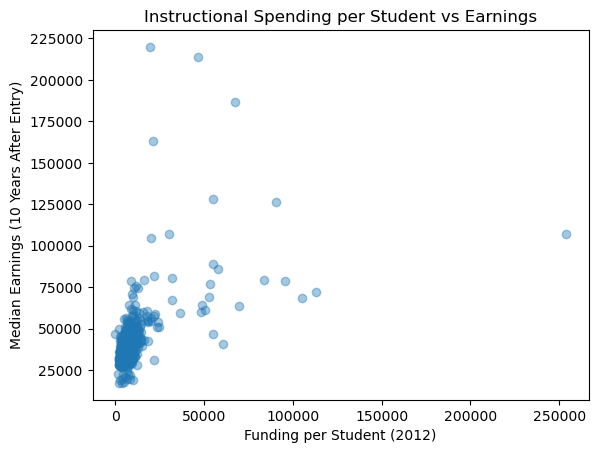

In [12]:
import matplotlib.pyplot as plt

plt.scatter(merged_model["funding_per_student_2012"], merged_model["MD_EARN_WNE_P10"], alpha=0.4)
plt.xlabel("Funding per Student (2012)")
plt.ylabel("Median Earnings (10 Years After Entry)")
plt.title("Instructional Spending per Student vs Earnings")
plt.show()

In [13]:
merged.to_csv(
    "data/02-processed/funding_earnings_2012_processed.csv",
    index=False
)

## Ethics 

### A. Data Collection
 - [X] **A.1 Informed consent**: Our project uses publicly available datasets collected by federal agencies. Since we have no direct interaction with human subjects, informed consent was handled by the original institutions under their legal and ethical frameworks.
 - [X] **A.2 Collection bias**: There may be collection bias due to how different institutions/districts report funding and how earnings are aggregated geographically. Missing or incomplete records may systematically differ from institutions with complete data. We will document missingness and interpret results cautiously.
 - [X] **A.3 Limit PII exposure**: No personally identifiable information (PII) is used in this project. All data are aggregated at the institution or regional level, preventing identification of individuals.
 - [X] **A.4 Downstream bias mitigation**: When available, variables such as race/ethnicity and gender distributions (or related composition measures) will be included to explore potential disparities in outcomes.

### B. Data Storage
 - [X] **B.1 Data security**: We rely on publicly available data sources and will avoid downloading unnecessary or sensitive data. We will keep dependencies up to date and store data in the repository only as needed for analysis.
 - [X] **B.2 Right to be forgotten**: Not applicable because we do not use PII and use only aggregated public data.
 - [X] **B.3 Data retention plan**: Not applicable because we do not store PII; we will retain only project-relevant, public, aggregated datasets.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Our datasets will not fully capture contextual factors such as local job opportunities, accessibility barriers, or other community support systems. We will acknowledge these limitations in our discussion.
 - [X] **C.2 Dataset bias**: We will explicitly state that correlations may reflect broader socioeconomic forces rather than a direct causal effect of institutional funding.
 - [X] **C.3 Honest representation**: We will present visualizations and summaries that reflect the underlying data accurately and avoid misleading scales or selective reporting.
 - [X] **C.4 Privacy in analysis**: We will not use or display PII, and will only analyze aggregated measures.
 - [X] **C.5 Auditability**: Our analysis will be reproducible and documented in the notebook with clear steps for data cleaning, merging, and modeling.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: We will avoid using protected attributes directly. Our models use institution-level funding rather than individual characteristics, and we include regional controls to reduce geographic variables acting as proxies for wealth demographics.
 - [X] **D.2 Fairness across groups**: We will evaluate whether model errors or residuals differ systematically across institution types (e.g., region, size), to ensure results do not consistently over- or under-estimate outcomes for particular groups of schools.
 - [X] **D.3 Metric selection**: In addition to standard model fit metrics, we will examine error distributions and uncertainty to ensure results are not misleading.
 - [X] **D.4 Explainability**: We will explain results in understandable terms (e.g., how funding and controls relate to predicted earnings) and highlight uncertainty and assumptions.
 - [X] **D.5 Communicate limitations**: We will communicate limitations in plain language, emphasizing that findings are correlational and context-dependent.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: If we extend the project, we would check model stability with updated data releases and re-evaluate assumptions.
 - [X] **E.2 Redress**: If results could plausibly contribute to harm or misinterpretation, we will revise analysis framing and clarify limitations and responsible interpretation.
 - [X] **E.3 Roll back**: Since this is an academic analysis (not a deployed system), results can be revised or withdrawn if issues are found.
 - [X] **E.4 Unintended use**: Our findings could be misused to oversimplify debates about school funding (e.g., implying low-earning outcomes justify budget cuts). We will emphasize that results are correlational and that many unmeasured factors influence earnings beyond what we analyze.


## Team Expectations 

1. **Weekly Sync:** We aim to check in with each other through iMessage every other day while meeting in person at least once a week, transitioning to Zoom if we feel additional meeting days will be beneficial to our group progress. We expect responses to messages within 24 hours, while indicating “urgent” for urgent issues.
2. **Communication Policies:** All communication will be direct and polite. Team members will listen actively to each other, assume good intentions, and encourage everyone to participate equally in discussions. To personally suggest something, a group member should send a message like: “I think X may not work because of Y” or “I think we may need to change X to Y because of Z.”
3. **Conflict Resolution:** We plan to use majority vote for most decisions. For minor decisions such as task assignments, we believe it is more straightforward to assign authority to designated members. If a decision is time-sensitive, we will proceed with the input of responsive teammates and inform any non-responsive teammates afterward.
4. **When a member is struggling:** If a team member is struggling to complete a task, they should notify the group as soon as possible (ideally via iMessage) within 24–28 hours explaining the task and the issue. The team will assess the situation and provide guidance/resources or help break the task into smaller parts. If needed, remaining work will be redistributed to meet deadlines while keeping workload balanced. If unresolved, the team will escalate the issue to a TA or the professor.


## Project Timeline Proposal

| Meeting Date | Meeting Time | Completed Before Meeting | Discuss at Meeting |
|---|---:|---|---|
| 2/1 | 2:00 PM | Read and review COGS 108 expectations; brainstorm potential topics and research questions | Decide on primary form of communication; finalize project topic; discuss initial hypothesis; begin background research |
| 2/3 | 2:00 PM | Conduct background research on the chosen topic | Identify ideal datasets (NCES, Census); discuss ethics considerations; draft initial project proposal |
| 2/4 | 2:00 PM | Edit, finalize, and submit the project proposal | Confirm dataset choices; discuss data wrangling strategy and analytical approaches; assign group leads |
| 2/14 | 2:00 PM | Import, merge, and format datasets; complete initial data cleaning | Review data wrangling progress; address data issues; plan remaining cleaning steps |
| 2/18 | No meeting (Checkpoint) | Checkpoint #1: Data — finalize datasets and complete initial cleaning | N/A |
| 2/23 | 2:00 PM | Finalize cleaned datasets; begin exploratory analysis | Review early EDA results; refine analysis plan; prepare for EDA checkpoint |
| 3/4 | No meeting (Checkpoint) | Checkpoint #2: EDA — complete EDA and generate initial visualizations | N/A |
| 3/13 | 2:00 PM | Complete statistical analysis; draft results and discussion sections | Review and edit full project draft; plan final revisions |
| 3/18 | Before 11:59 PM | Final Submission — Jupyter Notebook and 3–5 minute video | N/A |